In [ ]:
"""
TIMEPOINT COLOURS COME FROM paper_style
=======================================
Only the colours. This notebook is not on the paper_style figure convention yet, so
ps.use() is deliberately NOT called here -- importing the module changes nothing about
type size or panel size, it only makes the shared palette available. A timepoint is
then the same colour here as in the converted notebooks and on the poster: one ramp through magma
(coral -> crimson -> magenta -> deep purple), darkening Early -> Late -> Pre-rec ->
Proficient, so the darkest line is the most-trained one.

Call ps.use('poster') (or 'paper') below if you do want the full convention here too.
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

print('timepoint colours:', ps.TIMEPOINT)

In [1]:
"""
IS THE RELATIONAL STRUCTURE OF MICE PRESERVED ACROSS LEARNING?
==============================================================
The question this script answers, and the one it deliberately does NOT answer.

DOES answer: do mice that are behaviourally similar at one timepoint remain
similar at another? That is a statement about the mouse x mouse distance
structure WITHIN each timepoint, and it survives any smooth re-embedding of the
feature space between timepoints -- a rotation, a per-axis stretch, a monotone
warp, or a full non-linear deformation. Nothing has to be fitted, so it is
enormously better powered than learning a map from ~40 mice.

Does NOT answer: where a given mouse sits on the proficient LD1 axis. That needs
a transfer map (lda_pred.ipynb), and a map is exactly what a non-linear warp
breaks. Note also that CROSS-timepoint distances are meaningless here for the
same reason -- if the space warps, the distance from Early-mouse-A to
Late-mouse-A is not comparable to anything. Only within-space structure is.

Three views of the same question, all with mouse-permutation nulls:
  1. MANTEL     -- Spearman between the two timepoints' RDM upper triangles.
                   Global: does the whole distance structure correspond?
  2. kNN OVERLAP-- do a mouse's k nearest neighbours stay its neighbours?
                   Local: survives even a severe global warp that Mantel misses.
  3. CKA        -- centred kernel alignment between the two mouse kernels.
                   Distance-free second opinion, standard in representational
                   similarity work.

And the number without which none of the above can be interpreted:
  4. NOISE CEILING -- split each mouse's data in half, build an RDM from each
                   half, and Mantel them WITHIN a timepoint. That is how much
                   structure is reproducible at all. A cross-timepoint Mantel of
                   0.3 against a ceiling of 0.35 is near-perfect preservation; the
                   same 0.3 against a ceiling of 0.9 is a real breakdown.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

BASE_CANDIDATES = [
    '/home/ines/repositories/representation_learning_variability/paper-individuality/data/',
    os.path.expanduser('~/Documents/Repositories/representation_learning_variability/'
                       'paper-individuality/data/'),
]
base_path = next((p for p in BASE_CANDIDATES if os.path.isdir(p)), BASE_CANDIDATES[0])
print('base_path:', base_path)


base_path: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/


In [2]:
""" FEATURE BUILDING -- same conventions as lda_sweep_timepoints / lda_all_timepoints """


def filter_sequences(all_sequences, prob_sessions, min_sessions=1):
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    cnt = (all_sequences[['mouse_name', 'session']].drop_duplicates()
           .groupby(['mouse_name'])['session'].count().reset_index())
    keep = cnt.loc[cnt['session'] >= min_sessions, 'mouse_name']
    return all_sequences.loc[all_sequences['mouse_name'].isin(keep)].reset_index(drop=True)


def binarize(use_sequences, n_paw_states=8, keep_paw=True, keep_whisk=True, keep_lick=True):
    """One-hot paw state (reference state 1 dropped) + whisk + lick, per timestep."""
    if not (keep_paw or keep_whisk or keep_lick):
        raise ValueError("At least one feature type must be kept.")
    n_raw = n_paw_states + 2
    n_trials, timesteps = use_sequences.shape
    out = np.zeros((n_trials, timesteps * n_raw), dtype=np.float32)
    for t in range(timesteps):
        vals = use_sequences[:, t]
        nan_mask = np.isnan(vals); valid = ~nan_mask
        labels = vals[valid].astype(int); start = t * n_raw
        if len(labels):
            rows = np.arange(n_trials)[valid]
            out[rows, start + (labels % n_paw_states)] = 1
            out[valid, start + n_paw_states] = ((labels // n_paw_states) % 2).astype(int)
            out[valid, start + n_paw_states + 1] = (labels // (n_paw_states * 2)).astype(int)
        if np.any(nan_mask):
            out[nan_mask, start:start + n_raw] = np.nan
    cols = []
    if keep_paw:   cols += [i for i in range(n_paw_states) if i != 1]
    if keep_whisk: cols += [n_paw_states]
    if keep_lick:  cols += [n_paw_states + 1]
    return out[:, [t * n_raw + c for t in range(timesteps) for c in cols]]


def build_timepoint(path, prob_sessions, exclude, n_paw_states=8,
                    keep_paw=True, keep_whisk=True, keep_lick=True,
                    n_split_repeats=20, seed=0):
    """
    One feature vector per MOUSE at this timepoint, plus split-half replicates.

    Aggregation is session-mean first, then mouse-mean over sessions, so a mouse
    with 900 trials in one session does not outweigh one with 300 -- the same
    convention as the LDA sweep.

    The split halves are what the noise ceiling is computed from. A mouse with >=2
    sessions here is split BY SESSION (so the ceiling includes between-session
    variability, which is the honest noise for a mouse-level claim); a mouse with a
    single session is split by trials within it, which is the best available.

    Returns (mouse_means, halves, n_sessions_per_mouse):
        mouse_means : DataFrame, mice x features
        halves      : list of n_split_repeats (DataFrame A, DataFrame B) pairs,
                      each mice x features, aligned to mouse_means' index
        n_sessions  : Series, sessions per mouse at this timepoint
    """
    seq = pd.read_parquet(path)
    seq['session'] = seq['sample'].str[:36]
    seq = filter_sequences(seq, prob_sessions, min_sessions=1)
    seq = seq.loc[~seq['session'].isin(exclude)]

    design = (seq.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                        columns=['broader_label'], values='binned_sequence')
              .reset_index().dropna())
    design = design.sort_values(by=['mouse_name', 'session'])
    assert len(design) > 0, f"nothing left after filtering {os.path.basename(path)}"

    epochs = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
    seqs = np.vstack(design[epochs].apply(lambda r: np.hstack(r), axis=1))
    feats = binarize(seqs, n_paw_states, keep_paw, keep_whisk, keep_lick)
    assert len(feats) == len(design)

    trial_mouse = design['mouse_name'].values
    trial_sess = design['session'].values
    n_sessions = (pd.DataFrame({'m': trial_mouse, 's': trial_sess})
                  .drop_duplicates().groupby('m')['s'].count())

    def aggregate(row_mask):
        """session-mean then mouse-mean, over the trials selected by row_mask"""
        df = pd.DataFrame(feats[row_mask])
        df['session'] = trial_sess[row_mask]
        df['mouse_name'] = trial_mouse[row_mask]
        per_session = df.groupby(['mouse_name', 'session'], sort=True).mean()
        return per_session.groupby('mouse_name', sort=True).mean()

    mouse_means = aggregate(np.ones(len(feats), bool))

    rng = np.random.default_rng(seed)
    halves = []
    for _ in range(n_split_repeats):
        mask_a = np.zeros(len(feats), bool)
        for m in mouse_means.index:
            rows_m = np.where(trial_mouse == m)[0]
            sess_m = np.unique(trial_sess[rows_m])
            if len(sess_m) >= 2:                       # split by session
                half = rng.permutation(sess_m)[:len(sess_m) // 2]
                mask_a[rows_m] = np.isin(trial_sess[rows_m], half)
            else:                                      # split trials within session
                pick = rng.permutation(rows_m)[:len(rows_m) // 2]
                mask_a[pick] = True
        A, B = aggregate(mask_a), aggregate(~mask_a)
        common = mouse_means.index.intersection(A.index).intersection(B.index)
        halves.append((A.reindex(common), B.reindex(common)))

    print(f"  {os.path.basename(path)[:52]:52s} "
          f"{len(np.unique(trial_sess)):3d} sessions, {len(mouse_means):3d} mice, "
          f"{mouse_means.shape[1]:3d} features")
    return mouse_means, halves, n_sessions


In [3]:
""" RELATIONAL-STRUCTURE MEASURES """


def zscore_columns(df, mu=None, sd=None, eps=1e-8):
    """
    Z-score features WITHIN a timepoint. Distances are already translation
    invariant, so this is really about the scales: without it, a feature that
    happens to be more variable at one timepoint dominates that timepoint's RDM
    and the two RDMs stop being commensurate. mu/sd are passed in so the split
    halves get standardised with the FULL data's parameters, not their own.
    """
    X = np.asarray(df, dtype=float)
    if mu is None:
        mu, sd = X.mean(0), X.std(0)
    return pd.DataFrame((X - mu) / (sd + eps), index=df.index, columns=df.columns), mu, sd


def rdm(df, metric='correlation'):
    """Mouse x mouse dissimilarity matrix. Rows must already be the mice, in order."""
    return squareform(pdist(np.asarray(df, dtype=float), metric=metric))


def mantel_test(mat_a, mat_b, n_perm=10000, seed=42):
    """
    Mantel permutation test between two symmetric distance matrices.
    Permutes the rows/columns of mat_a -- i.e. shuffles WHICH MOUSE IS WHICH in one
    space, which is exactly the null "the two spaces order mice unrelatedly".
    (verbatim from neural_rsa.ipynb so the two analyses report the same statistic)
    """
    n = mat_a.shape[0]
    idx = np.triu_indices(n, k=1)
    observed_r, _ = spearmanr(mat_a[idx], mat_b[idx])

    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(n)
        r_perm, _ = spearmanr(mat_a[np.ix_(perm, perm)][idx], mat_b[idx])
        if r_perm >= observed_r:
            count += 1

    p = (count + 1) / (n_perm + 1)  # +1 for observed itself
    return observed_r, p


def knn_overlap(mat_a, mat_b, k=5):
    """
    Mean fraction of a mouse's k nearest neighbours that are shared between the two
    spaces. Local rather than global: a warp that scrambles long distances but keeps
    neighbourhoods intact shows up here and not in the Mantel.
    Chance is roughly k / (n - 1).
    """
    n = mat_a.shape[0]
    k = min(k, n - 1)
    def neighbours(M):
        out = []
        for i in range(n):
            d = M[i].copy(); d[i] = np.inf
            out.append(set(np.argsort(d)[:k]))
        return out
    na, nb = neighbours(mat_a), neighbours(mat_b)
    return float(np.mean([len(na[i] & nb[i]) / k for i in range(n)]))


def knn_overlap_test(mat_a, mat_b, k=5, n_perm=2000, seed=42):
    obs = knn_overlap(mat_a, mat_b, k)
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(mat_a.shape[0])
        null[i] = knn_overlap(mat_a[np.ix_(perm, perm)], mat_b, k)
    p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    return obs, float(null.mean()), p


def cka(X, Y):
    """
    Centred kernel alignment between the linear mouse kernels of two spaces.
    Invariant to rotation and isotropic scaling of either space, so it asks the same
    preservation question without ever forming distances.
    (_cka from neural_rsa.ipynb, wrapped to take feature matrices)
    """
    K1 = np.asarray(X, float) @ np.asarray(X, float).T
    K2 = np.asarray(Y, float) @ np.asarray(Y, float).T
    n = K1.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    K1c, K2c = H @ K1 @ H, H @ K2 @ H
    hsic = np.sum(K1c * K2c)
    norm = np.sqrt(np.sum(K1c ** 2) * np.sum(K2c ** 2))
    return hsic / (norm + 1e-10)


def cka_test(X, Y, n_perm=2000, seed=42):
    obs = cka(X, Y)
    rng = np.random.default_rng(seed)
    Xa = np.asarray(X, float)
    null = np.empty(n_perm)
    for i in range(n_perm):
        null[i] = cka(Xa[rng.permutation(len(Xa))], Y)
    p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    return float(obs), float(null.mean()), p


def noise_ceiling(halves, cohort, metric='correlation', mu=None, sd=None):
    """
    Split-half reliability of a timepoint's RDM: build an RDM from each half and
    Spearman their upper triangles, averaged over the split repeats.

    Spearman-Brown corrects for the fact that each half has only half the data,
    giving the reliability of the FULL-data RDM -- which is the quantity that
    actually bounds a cross-timepoint correlation.
    """
    rs = []
    for A, B in halves:
        keep = [m for m in cohort if m in A.index and m in B.index]
        if len(keep) < 4:
            continue
        Az, _, _ = zscore_columns(A.loc[keep], mu, sd)
        Bz, _, _ = zscore_columns(B.loc[keep], mu, sd)
        Ra, Rb = rdm(Az, metric), rdm(Bz, metric)
        idx = np.triu_indices(len(keep), k=1)
        rs.append(spearmanr(Ra[idx], Rb[idx])[0])
    if not rs:
        return np.nan, np.nan
    r_half = float(np.mean(rs))
    sb = 2 * r_half / (1 + r_half) if r_half > -1 else np.nan   # Spearman-Brown
    return r_half, sb


In [ ]:
""" CONFIG """

from pathlib import Path
# A long-lived kernel caches imported modules, so edits to session_filters -- or
# the QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint, CSV_NAME


def find_qc_csv():
    """
    session_filters resolves the QC sheet as Path(__file__).with_name(CSV_NAME), so
    it breaks whenever the module and the sheet sit in different folders (they do
    right now: the module was moved to learning_individuality, the sheet stayed in
    4_mice). Look in the obvious places and hand the path over explicitly.
    """
    here = Path(__file__).parent if '__file__' in globals() else Path.cwd()
    for cand in [here / CSV_NAME,
                 here.parent / '4_mice' / CSV_NAME,
                 *sorted(here.parent.glob(f'*/{CSV_NAME}'))]:
        if cand.exists():
            return str(cand)
    raise FileNotFoundError(f"{CSV_NAME} not found near {here}")


# THE FILTER PARAMETER:
#   'filtered_out'            -> drop Used in paper == 'filtered out'
#   'filtered_out_and_revise' -> drop those PLUS 'need to revise'
QC_STRICTNESS = 'filtered_out'
QC_CSV = find_qc_csv()
print(f"QC sheet: {QC_CSV}")
_excl = exclusions_by_timepoint(QC_STRICTNESS, csv_path=QC_CSV)
prob_sessions = _excl['Proficient']
print(f"exclusions ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in _excl.items()))

TIMEPOINTS = {
    'Early':      dict(file=base_path + 'training/' + 'paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
                       excl='Early',      label='Early learning', color=ps.TIMEPOINT['Early']),
    'Late':       dict(file=base_path + 'training/' + 'paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026',
                       excl='Late',       label='Late learning',  color=ps.TIMEPOINT['Late']),
    # this name was ..._28-08-2026, which is not on disk -- the missing-file check
    # below then SILENTLY dropped Pre-rec, the strongest timepoint, from everything
    'Pre-rec':    dict(file=base_path + 'training/' + 'paw_wheel_biased_8_k_10_bin_syllables_04-09-2026',
                       excl='Pre-rec',    label='Pre-recording',  color=ps.TIMEPOINT['Pre-rec']),
    'Proficient': dict(file=base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026',
                       excl='Proficient', label='Proficient',     color=ps.TIMEPOINT['Proficient']),
}

# ============================== EDIT ME ==============================
# Which timepoints to compare. Every pair among these is tested, and the
# cohort is the mice present at ALL of them -- an RDM pair has to be over
# the same mice, so unlike the LDA sweep this is not optional.
USE_TIMEPOINTS = ['Early', 'Late', 'Pre-rec', 'Proficient']

METRIC       = 'correlation'  # RDM dissimilarity: 'correlation' or 'euclidean'
K_NN         = 5              # neighbourhood size for the kNN-overlap test
N_PERM       = 10000          # Mantel permutations (p floor = 1/(N_PERM+1))
N_PERM_FAST  = 2000           # permutations for the kNN and CKA tests
N_SPLITS     = 20             # split-half repeats for the noise ceiling
STANDARDIZE  = True           # z-score features within each timepoint
KEEP_PAW, KEEP_WHISK, KEEP_LICK = True, True, True
# =====================================================================

unknown = [t for t in USE_TIMEPOINTS if t not in TIMEPOINTS]
assert not unknown, f"unknown timepoint(s) {unknown}; choose from {list(TIMEPOINTS)}"
missing = [t for t in USE_TIMEPOINTS if not os.path.exists(TIMEPOINTS[t]['file'])]
if missing:
    print(f"!! dropping timepoint(s) with no file on disk: {missing}")
    USE_TIMEPOINTS = [t for t in USE_TIMEPOINTS if t not in missing]
assert len(USE_TIMEPOINTS) >= 2, "need at least two timepoints to compare"
print(f"comparing {USE_TIMEPOINTS} | metric={METRIC} k={K_NN}")


In [5]:
""" BUILD -- one mouse-level matrix per timepoint, plus split halves """

built = {}
for name in USE_TIMEPOINTS:
    tp = TIMEPOINTS[name]
    print(f"\n=== {name}")
    means, halves, n_sess = build_timepoint(
        tp['file'], prob_sessions, _excl[tp['excl']],
        keep_paw=KEEP_PAW, keep_whisk=KEEP_WHISK, keep_lick=KEEP_LICK,
        n_split_repeats=N_SPLITS)
    built[name] = dict(means=means, halves=halves, n_sessions=n_sess)

# The cohort: mice with data at EVERY selected timepoint
cohort = sorted(set.intersection(*[set(b['means'].index) for b in built.values()]))
assert len(cohort) >= 6, (f"only {len(cohort)} mice have all of {USE_TIMEPOINTS}; "
                          f"an RDM over that few mice is not worth testing")
print(f"\nCOHORT: {len(cohort)} mice present at all of {USE_TIMEPOINTS}")
for name in USE_TIMEPOINTS:
    print(f"  {name:11s} {len(built[name]['means']):3d} mice here, "
          f"{len(set(built[name]['means'].index) - set(cohort)):3d} dropped as incomplete")

# Restrict, drop features that are constant across the cohort anywhere, standardise
feat = built[USE_TIMEPOINTS[0]]['means'].columns
for name in USE_TIMEPOINTS:
    Xc = built[name]['means'].loc[cohort]
    feat = feat.intersection(Xc.columns[np.asarray(Xc, float).std(0) > 1e-10])
print(f"{len(feat)} of {built[USE_TIMEPOINTS[0]]['means'].shape[1]} features kept "
      f"(non-constant across the cohort at every timepoint)")

for name in USE_TIMEPOINTS:
    Xc = built[name]['means'].loc[cohort, feat]
    if STANDARDIZE:
        Xz, mu, sd = zscore_columns(Xc)
    else:
        Xz, mu, sd = Xc, None, None
    built[name].update(X=Xz, mu=mu, sd=sd,
                       halves=[(A.reindex(columns=feat), B.reindex(columns=feat))
                               for A, B in built[name]['halves']])
    built[name]['rdm'] = rdm(Xz, METRIC)



=== Early
  paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026   37 sessions,  37 mice, 360 features

=== Late
  paw_wheel_last_training_8_k_10_bin_syllables_04-09-2  49 sessions,  49 mice, 360 features

=== Pre-rec
  paw_wheel_biased_8_k_10_bin_syllables_04-09-2026      96 sessions,  37 mice, 360 features

=== Proficient
  paw_wheel_8_k_10_bin_syllables_28-08-2026            330 sessions, 101 mice, 360 features

COHORT: 19 mice present at all of ['Early', 'Late', 'Pre-rec', 'Proficient']
  Early        37 mice here,  18 dropped as incomplete
  Late         49 mice here,  30 dropped as incomplete
  Pre-rec      37 mice here,  18 dropped as incomplete
  Proficient  101 mice here,  82 dropped as incomplete
353 of 360 features kept (non-constant across the cohort at every timepoint)


In [6]:
"""
HOW MANY MICE DOES EACH CHOICE OF TIMEPOINTS LEAVE?
An RDM pair has to be over the SAME mice, so the cohort is an intersection and it
shrinks fast -- Pre-rec exists only for recorded mice, and its QC exclusions remove
6 mice entirely. Check this before settling on USE_TIMEPOINTS above.
"""
from itertools import combinations

avail = {name: set(b['means'].index) for name, b in built.items()}
print(f"{'timepoints':46s} {'cohort':>7s}")
for k in range(2, len(avail) + 1):
    for combo in combinations(avail, k):
        n = len(set.intersection(*[avail[c] for c in combo]))
        print(f"{' + '.join(combo):46s} {n:7d}")


timepoints                                      cohort
Early + Late                                        35
Early + Pre-rec                                     19
Early + Proficient                                  37
Late + Pre-rec                                      31
Late + Proficient                                   49
Pre-rec + Proficient                                37
Early + Late + Pre-rec                              19
Early + Late + Proficient                           35
Early + Pre-rec + Proficient                        19
Late + Pre-rec + Proficient                         31
Early + Late + Pre-rec + Proficient                 19


In [7]:
""" NOISE CEILING -- how much RDM structure is reproducible within a timepoint? """

print(f"split-half reliability of each timepoint's RDM ({N_SPLITS} splits, "
      f"session-level split where a mouse has >1 session)")
print(f"  {'timepoint':12s} {'sess/mouse':>10s} {'half-half rho':>14s} {'full-data rel.':>15s}")
for name in USE_TIMEPOINTS:
    b = built[name]
    r_half, sb = noise_ceiling(b['halves'], cohort, METRIC, b['mu'], b['sd'])
    b['rel_half'], b['rel'] = r_half, sb
    spm = b['n_sessions'].reindex(cohort).mean()
    print(f"  {name:12s} {spm:10.1f} {r_half:14.3f} {sb:15.3f}")

print("\nA cross-timepoint Mantel cannot exceed sqrt(rel_A * rel_B). That ceiling, "
      "\nnot 1.0, is what 'fully preserved' means.")


split-half reliability of each timepoint's RDM (20 splits, session-level split where a mouse has >1 session)
  timepoint    sess/mouse  half-half rho  full-data rel.
  Early               1.0          0.742           0.852
  Late                1.0          0.844           0.916
  Pre-rec             2.5          0.579           0.733
  Proficient          3.9          0.471           0.641

A cross-timepoint Mantel cannot exceed sqrt(rel_A * rel_B). That ceiling, 
not 1.0, is what 'fully preserved' means.


In [8]:
""" THE TESTS -- every pair of timepoints """

pairs = [(a, b) for i, a in enumerate(USE_TIMEPOINTS) for b in USE_TIMEPOINTS[i+1:]]
rows = []
chance_knn = K_NN / (len(cohort) - 1)

print(f"{len(cohort)} mice | kNN chance = {chance_knn:.3f} | "
      f"Mantel p floor = {1/(N_PERM+1):.2g}\n")
for a, b in pairs:
    Ra, Rb = built[a]['rdm'], built[b]['rdm']
    r_mantel, p_mantel = mantel_test(Ra, Rb, n_perm=N_PERM)
    ceiling = float(np.sqrt(max(built[a]['rel'], 0) * max(built[b]['rel'], 0)))
    knn, knn_null, knn_p = knn_overlap_test(Ra, Rb, K_NN, N_PERM_FAST)
    c, c_null, c_p = cka_test(built[a]['X'], built[b]['X'], N_PERM_FAST)
    rows.append(dict(pair=f'{a} vs {b}', mantel_rho=r_mantel, mantel_p=p_mantel,
                     ceiling=ceiling,
                     mantel_corrected=r_mantel / ceiling if ceiling > 0 else np.nan,
                     knn=knn, knn_null=knn_null, knn_p=knn_p,
                     cka=c, cka_null=c_null, cka_p=c_p))
    print(f"{a} vs {b}")
    print(f"   Mantel rho = {r_mantel:+.3f}  p = {p_mantel:.4g} | ceiling {ceiling:.3f} "
          f"-> {r_mantel/ceiling if ceiling>0 else np.nan:+.3f} of what is reproducible")
    print(f"   kNN overlap = {knn:.3f} (null {knn_null:.3f}, p = {knn_p:.4g})")
    print(f"   CKA         = {c:.3f} (null {c_null:.3f}, p = {c_p:.4g})")

res = pd.DataFrame(rows)
print()
print(res.to_string(index=False, float_format=lambda v: f'{v:.3f}'))


19 mice | kNN chance = 0.278 | Mantel p floor = 0.0001

Early vs Late
   Mantel rho = +0.019  p = 0.3738 | ceiling 0.883 -> +0.022 of what is reproducible
   kNN overlap = 0.263 (null 0.278, p = 0.6167)
   CKA         = 0.461 (null 0.433, p = 0.2464)
Early vs Pre-rec
   Mantel rho = +0.070  p = 0.1717 | ceiling 0.790 -> +0.089 of what is reproducible
   kNN overlap = 0.305 (null 0.277, p = 0.3108)
   CKA         = 0.419 (null 0.408, p = 0.3493)
Early vs Proficient
   Mantel rho = +0.238  p = 0.005899 | ceiling 0.739 -> +0.322 of what is reproducible
   kNN overlap = 0.442 (null 0.277, p = 0.002499)
   CKA         = 0.562 (null 0.423, p = 0.004998)
Late vs Pre-rec
   Mantel rho = +0.181  p = 0.024 | ceiling 0.819 -> +0.221 of what is reproducible
   kNN overlap = 0.432 (null 0.278, p = 0.004498)
   CKA         = 0.574 (null 0.431, p = 0.004998)
Late vs Proficient
   Mantel rho = +0.227  p = 0.005599 | ceiling 0.766 -> +0.296 of what is reproducible
   kNN overlap = 0.411 (null 0.278, p 

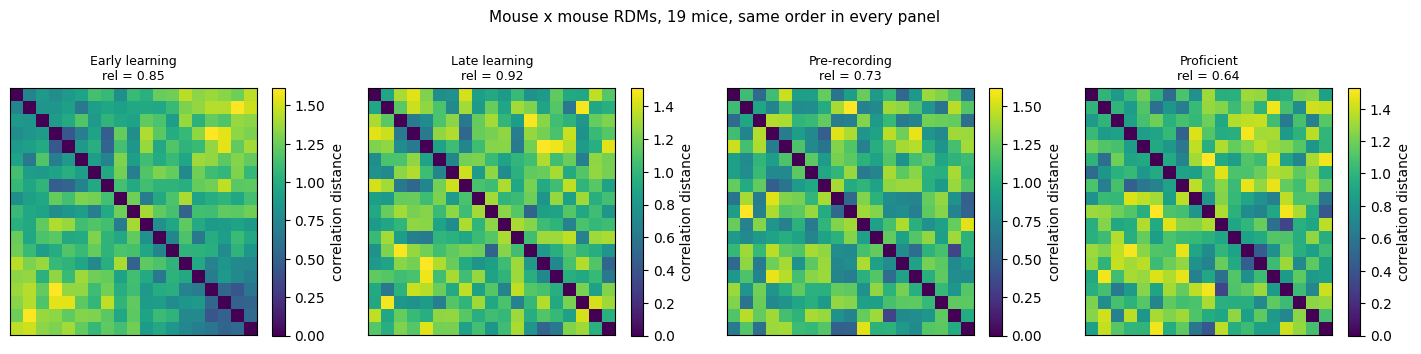

In [9]:
""" FIGURE 1 -- the RDMs themselves, mice in one common order """

# Order mice by their position on the first timepoint's leading structure, so a
# preserved relational structure shows as the same block pattern in every panel.
ref = built[USE_TIMEPOINTS[0]]
from sklearn.decomposition import PCA
order_key = PCA(1, random_state=0).fit_transform(np.asarray(ref['X'], float))[:, 0]
order = np.argsort(order_key)

fig, axes = plt.subplots(1, len(USE_TIMEPOINTS),
                         figsize=(3.6 * len(USE_TIMEPOINTS), 3.9))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, USE_TIMEPOINTS):
    M = built[name]['rdm'][np.ix_(order, order)]
    im = ax.imshow(M, cmap='viridis')
    ax.set_title(f"{TIMEPOINTS[name]['label']}\nrel = {built[name]['rel']:.2f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.75, label=f'{METRIC} distance')
fig.suptitle(f'Mouse x mouse RDMs, {len(cohort)} mice, same order in every panel', fontsize=11)
plt.tight_layout(); plt.show()


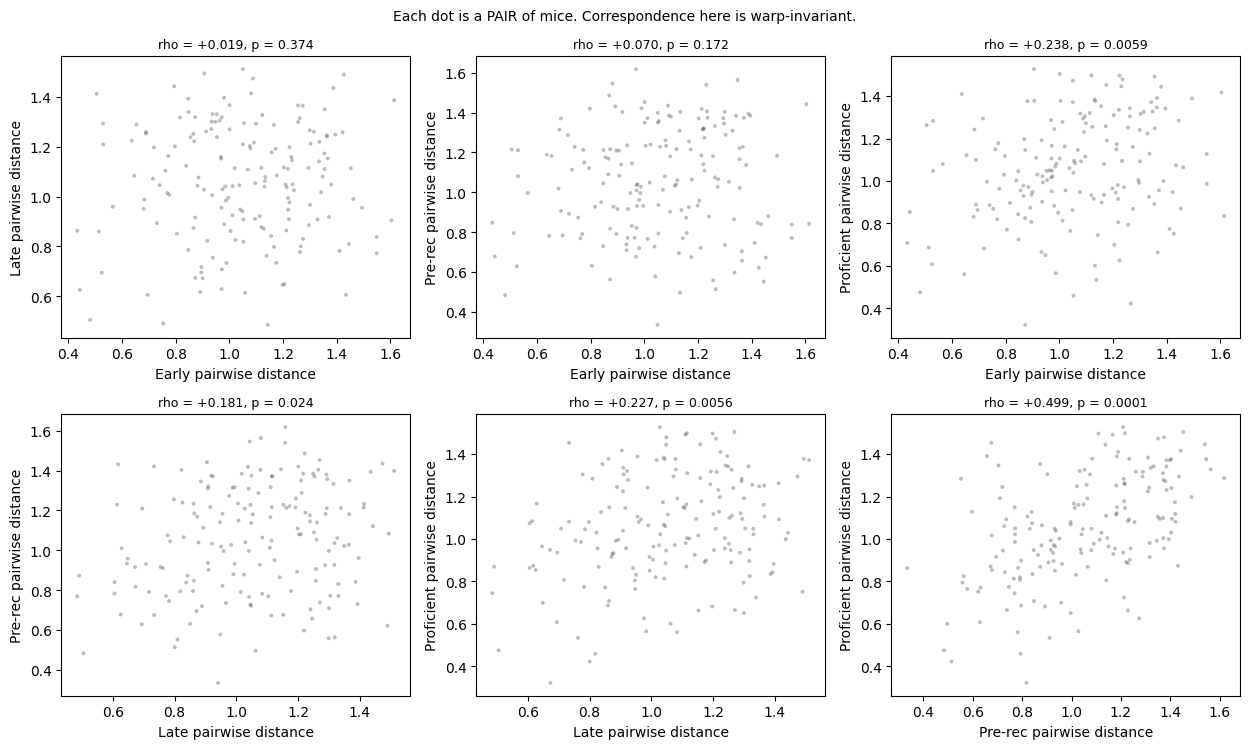

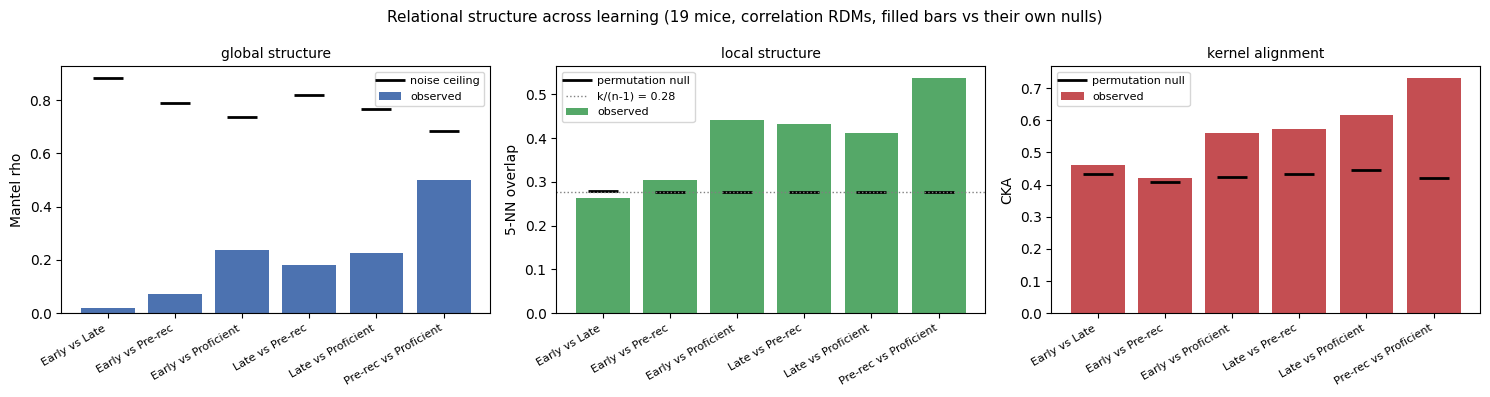

In [10]:
""" FIGURE 2 -- pairwise distances against each other, and the summary bars """

idx = np.triu_indices(len(cohort), k=1)
ncol = min(3, len(pairs))
nrow = int(np.ceil(len(pairs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.8 * nrow), squeeze=False)
for ax, (a, b) in zip(axes.ravel(), pairs):
    da, db = built[a]['rdm'][idx], built[b]['rdm'][idx]
    ax.scatter(da, db, s=8, alpha=0.35, edgecolors='none', color='#444')
    r = res.loc[res['pair'] == f'{a} vs {b}', 'mantel_rho'].iloc[0]
    p = res.loc[res['pair'] == f'{a} vs {b}', 'mantel_p'].iloc[0]
    ax.set_xlabel(f'{a} pairwise distance'); ax.set_ylabel(f'{b} pairwise distance')
    ax.set_title(f'rho = {r:+.3f}, p = {p:.3g}', fontsize=9)
for ax in axes.ravel()[len(pairs):]:
    ax.axis('off')
fig.suptitle('Each dot is a PAIR of mice. Correspondence here is warp-invariant.', fontsize=10)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.arange(len(res))

axes[0].bar(x, res['mantel_rho'], color='#4C72B0', label='observed')
axes[0].plot(x, res['ceiling'], 'k_', ms=22, mew=2, label='noise ceiling')
axes[0].axhline(0, color='grey', lw=0.8)
axes[0].set_ylabel('Mantel rho'); axes[0].set_title('global structure', fontsize=10)
axes[0].legend(fontsize=8)

axes[1].bar(x, res['knn'], color='#55A868', label='observed')
axes[1].plot(x, res['knn_null'], 'k_', ms=22, mew=2, label='permutation null')
axes[1].axhline(chance_knn, color='grey', ls='dotted', lw=1, label=f'k/(n-1) = {chance_knn:.2f}')
axes[1].set_ylabel(f'{K_NN}-NN overlap'); axes[1].set_title('local structure', fontsize=10)
axes[1].legend(fontsize=8)

axes[2].bar(x, res['cka'], color='#C44E52', label='observed')
axes[2].plot(x, res['cka_null'], 'k_', ms=22, mew=2, label='permutation null')
axes[2].set_ylabel('CKA'); axes[2].set_title('kernel alignment', fontsize=10)
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(res['pair'], rotation=30, ha='right', fontsize=8)
fig.suptitle(f'Relational structure across learning ({len(cohort)} mice, '
             f'{METRIC} RDMs, filled bars vs their own nulls)', fontsize=11)
plt.tight_layout(); plt.show()


## How to read the output

```
----------------------
Mantel p < 0.05 with a corrected rho near 1
    The structure is preserved as well as the data allow. Whatever the embedding
    does between timepoints, it keeps the arrangement of mice -- so individuality
    is there early, and lda_pred's failure is a failure of the linear TRANSFER MAP,
    not evidence against early individuality. Next step: the alignment ladder
    (Procrustes -> per-axis monotone -> kernel) to characterise the warp.

Mantel n.s. but kNN overlap significant
    Only local structure survives: near neighbours stay neighbours while the global
    geometry is deformed. That is the signature of a genuinely non-linear warp, and
    it argues for neighbourhood-based methods (kNN regression on the RDM, diffusion
    maps) over any global linear model.

Everything n.s. with a high ceiling
    The RDMs are reliable and they genuinely disagree: the arrangement of mice is
    reorganised across learning. No transfer model can work, and the honest claim
    is that individuality at this level is not conserved.

Everything n.s. with a LOW ceiling
    The measurement, not the biology, is the limit -- a single training session per
    mouse does not pin its position down. Fix the ceiling first (more sessions per
    mouse, fewer/denoised features); nothing else is interpretable until then.
```
